<a href="https://colab.research.google.com/github/SalvarezJ/Crib-Sentry/blob/main/notebooks/06_train_child.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crib Sentry: Child Detector Training
Here, I train a detector that finds only the child. I use Baby in Crib, BASE crib only BABY only and Baby object detection final (VTAR).

In [1]:
!pip install -q ultralytics roboflow

from google.colab import drive, userdata
drive.mount('/content/drive')

from roboflow import Roboflow
rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))

base_project = rf.workspace("first-workspace-9obfx").project("base-crib-only-baby-only-7ytse")
obj_project = rf.workspace("pd-qrqij").project("objetos_bebes")

for p in [base_project, obj_project]:
    for v in p.versions():
        print(v.id)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.8/336.8 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 121.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 10.7 MB/s eta 0:00:00
Mounted at /content/drive
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
first-workspace-9obfx/base-crib-only-baby-only-7ytse/3
first-workspace-9obfx/base-crib-only-baby-only-7ytse/2
first-workspace-9obfx/base-crib-only-baby-only-7ytse/1
pd-qrqij/objetos_bebes/3
pd-qrqij/objetos_bebes/2
pd-qrqij/objetos_bebes/1


## Download the datasets
I download each version to see which one has added copies.

In [2]:
import glob, os

bic = rf.workspace("test-1caua").project("baby-in-crib").version(1).download("yolov11")

for p, tag in [(base_project, 'BASE'), (obj_project, 'OBJ')]:
    for n in [1, 2, 3]:
        d = p.version(n).download("yolov11")
        counts = [len(glob.glob(f'{d.location}/{s}/images/*')) for s in ['train', 'valid', 'test']]
        print(tag, 'version', n, '| train, valid, test:', counts)
        !grep -E "nc:|names:" {d.location}/data.yaml

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Baby-in-Crib-1 in yolov11:: 100%|██████████| 496/496 [00:00<00:00, 2980.59it/s]


Extracting Dataset Version Zip to BASE-crib-only-BABY-only-1 in yolov11:: 100%|██████████| 1111/1111 [00:00<00:00, 3471.00it/s]


BASE version 1 | train, valid, test: [307, 91, 155]
nc: 1
names: ['baby']



Extracting Dataset Version Zip to BASE-crib-only-BABY-only-2 in yolov11:: 100%|██████████| 1111/1111 [00:00<00:00, 6112.84it/s]


...

OBJ version 1 | train, valid, test: [683, 149, 75]
nc: 5
names: ['baby-lying-on-back', 'baby-lying-on-stomach', 'baby-toy', 'baby-with-object', 'no-baby']



Extracting Dataset Version Zip to objetos_bebes-2 in yolov11:: 100%|██████████| 6926/6926 [00:00<00:00, 7381.46it/s]


OBJ version 2 | train, valid, test: [2944, 341, 172]
nc: 4
names: ['baby-lying-on-back', 'baby-lying-on-stomach', 'lado', 'no-baby']



Extracting Dataset Version Zip to objetos_bebes-3 in yolov11:: 100%|██████████| 14998/14998 [00:02<00:00, 7353.66it/s]


OBJ version 3 | train, valid, test: [6980, 341, 172]
nc: 4
names: ['baby-lying-on-back', 'baby-lying-on-side', 'baby-lying-on-stomach', 'no-baby']


## Count the original images
I count the original images in each folder and the boxes for each class.v

In [3]:
import re
from collections import Counter

def base_id(path):
    name = os.path.basename(path).split('.rf.')[0]
    return re.sub(r'_(jpg|jpeg|png)$', '', name)

for folder in ['/content/BASE-crib-only-BABY-only-3', '/content/objetos_bebes-2', '/content/objetos_bebes-3']:
    ids = {}
    for s in ['train', 'valid', 'test']:
        ids[s] = set(base_id(f) for f in glob.glob(f'{folder}/{s}/images/*'))
    classes = Counter()
    for f in glob.glob(f'{folder}/*/labels/*.txt'):
        for line in open(f).read().strip().splitlines():
            classes[line.split()[0]] += 1
    print(folder)
    print('  different images in train, valid, test:', len(ids['train']), len(ids['valid']), len(ids['test']))
    print('  in train and valid:', len(ids['train'] & ids['valid']), '| in train and test:', len(ids['train'] & ids['test']))
    print('  boxes for each class number:', sorted(classes.items()))

/content/BASE-crib-only-BABY-only-3
  different images in train, valid, test: 149 34 129
  in train and valid: 3 | in train and test: 0
  boxes for each class number: [('0', 453)]
/content/objetos_bebes-2
  different images in train, valid, test: 1801 326 164
  in train and valid: 102 | in train and test: 62
  boxes for each class number: [('0', 1383), ('1', 1172), ('2', 853), ('3', 35)]
/content/objetos_bebes-3
  different images in train, valid, test: 1801 326 164
  in train and valid: 102 | in train and test: 62
  boxes for each class number: [('0', 2971), ('1', 1858), ('2', 2565), ('3', 66)]


## First child folder
I keep one file for each original image and put each original in only one folder.

In [4]:
import shutil

out = '/content/child'
for s in ['train', 'valid']:
    os.makedirs(f'{out}/{s}/images', exist_ok=True)
    os.makedirs(f'{out}/{s}/labels', exist_ok=True)

def add(img, split, prefix, keep):
    name = prefix + os.path.basename(img)
    shutil.copy(img, f'{out}/{split}/images/{name}')
    label = img.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    new_lines = []
    for line in open(label).read().strip().splitlines():
        parts = line.split()
        if parts[0] not in keep:
            continue
        nums = [float(n) for n in parts[1:]]
        if len(nums) > 4:
            xs, ys = nums[0::2], nums[1::2]
            x1, x2, y1, y2 = min(xs), max(xs), min(ys), max(ys)
            nums = [(x1+x2)/2, (y1+y2)/2, x2-x1, y2-y1]
        new_lines.append(f'0 {nums[0]} {nums[1]} {nums[2]} {nums[3]}')
    open(f'{out}/{split}/labels/' + name.rsplit('.', 1)[0] + '.txt', 'w').write('\n'.join(new_lines))

for s in ['train', 'valid']:
    for img in glob.glob(f'{bic.location}/{s}/images/*'):
        add(img, s, 'BC_', ['0'])

for folder, prefix, keep in [('/content/BASE-crib-only-BABY-only-3', 'BA_', ['0']),
                             ('/content/objetos_bebes-3', 'OB_', ['0', '1', '2'])]:
    first = {}
    for img in sorted(glob.glob(f'{folder}/*/images/*')):
        first.setdefault(base_id(img), img)
    ids = sorted(first)
    for n, i in enumerate(ids):
        add(first[i], 'valid' if n % 10 == 0 else 'train', prefix, keep)
    print(prefix, 'original images:', len(ids))

for s in ['train', 'valid']:
    print(s, len(glob.glob(f'{out}/{s}/images/*')), 'images',
          len(glob.glob(f'{out}/{s}/labels/*')), 'label files')

BA_ original images: 309
OB_ original images: 2123
train 2357 images 2357 label files
valid 293 images 293 label files


## Check the boxes
The objetos_bebes boxes are on the head or a part of the body, not on the full baby. I ended up not using this dataset.

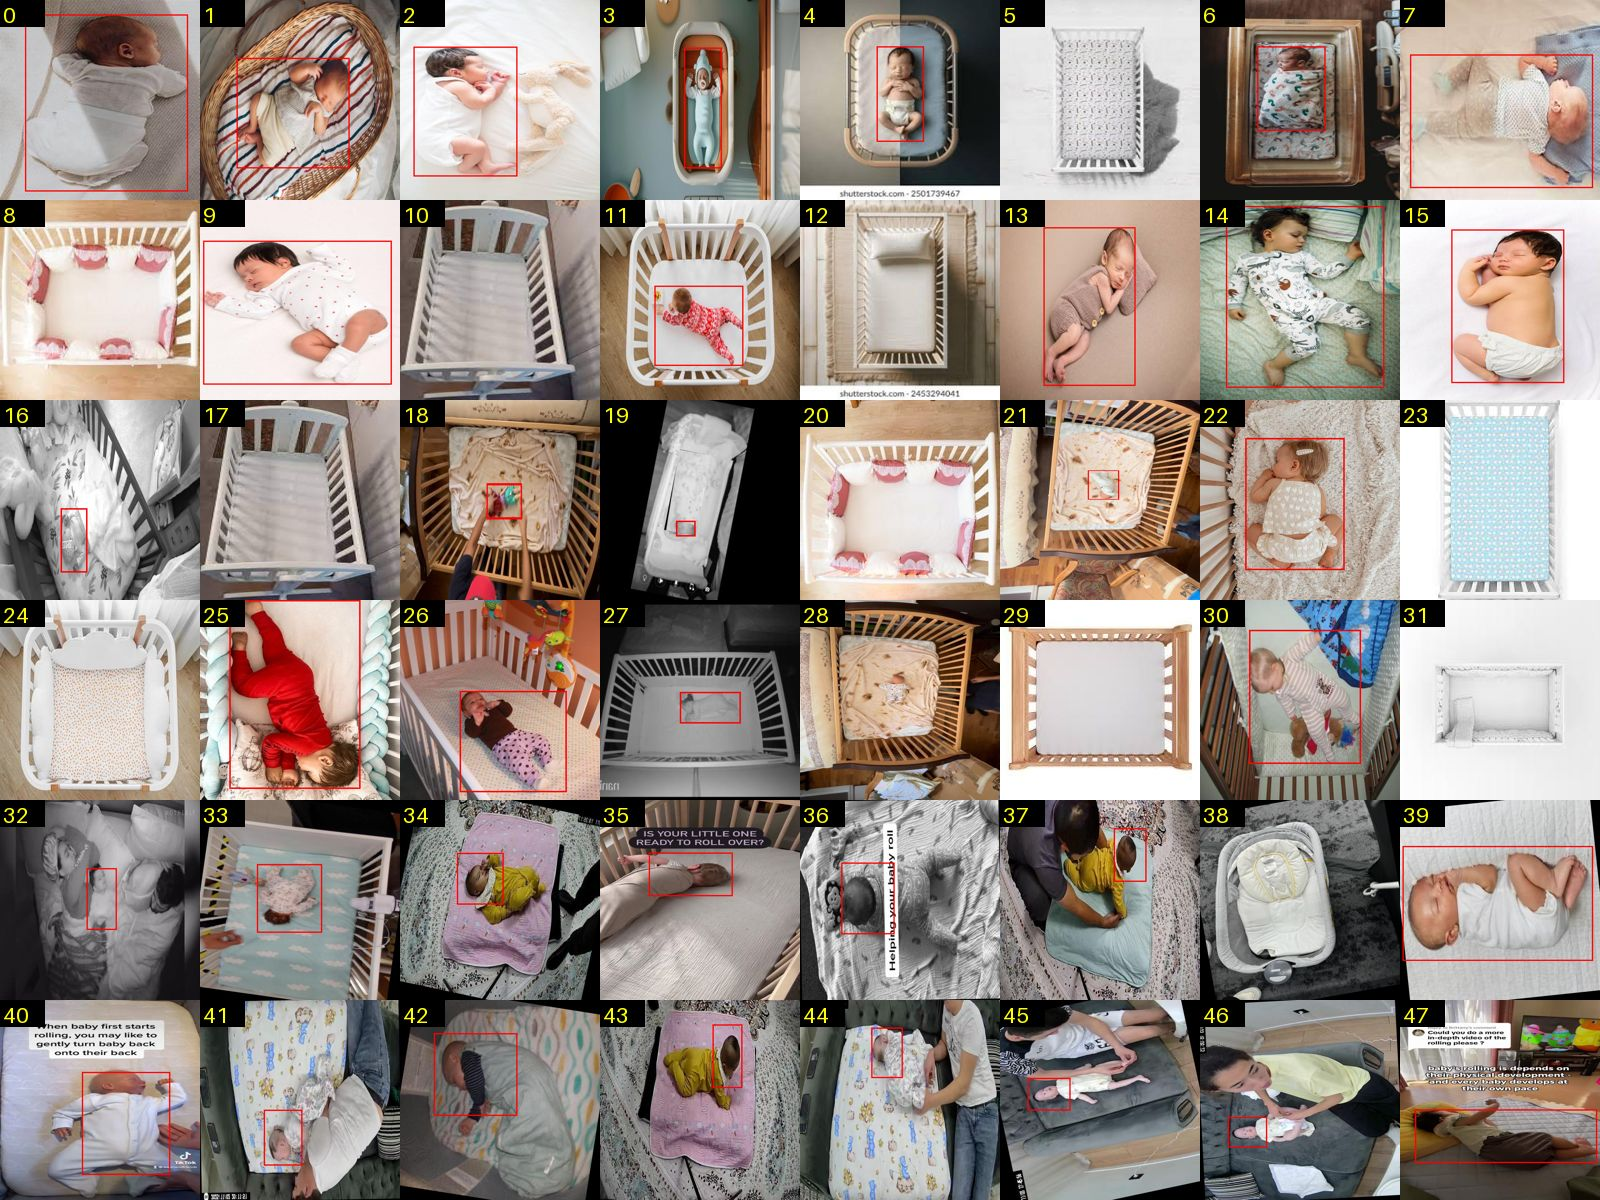

In [5]:
import random
from PIL import Image as PILImage, ImageDraw, ImageFont
from IPython.display import Image, display

def sheet(paths, file, size=200, cols=8):
    rows = (len(paths) + cols - 1) // cols
    page = PILImage.new('RGB', (cols * size, rows * size), 'white')
    font = ImageFont.load_default(size=22)
    for i, p in enumerate(paths):
        im = PILImage.open(p).convert('RGB')
        w, h = im.size
        draw = ImageDraw.Draw(im)
        label = p.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
        for line in open(label).read().strip().splitlines():
            c, x, y, bw, bh = [float(n) for n in line.split()]
            draw.rectangle([(x - bw/2) * w, (y - bh/2) * h, (x + bw/2) * w, (y + bh/2) * h],
                           outline='red', width=max(3, w // 150))
        im = im.resize((size, size))
        d = ImageDraw.Draw(im)
        d.rectangle([0, 0, 44, 26], fill='black')
        d.text((3, 1), str(i), fill='yellow', font=font)
        page.paste(im, ((i % cols) * size, (i // cols) * size))
    page.save(file, quality=80)
    display(Image(filename=file))

random.seed(0)
sample = []
for prefix in ['BC_', 'BA_', 'OB_']:
    sample += random.sample(sorted(glob.glob(f'{out}/train/images/{prefix}*')), 16)
sheet(sample, '/content/child_sample.jpg')

## Check VTAR
The VTAR boxes are on the full child. My 10 "left the crib" test images come from this dataset, so I list the videos.

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Baby-object-detection-final-1 in yolov11:: 100%|██████████| 15718/15718 [00:02<00:00, 6487.16it/s]


nc: 1
names: ['baby']
images: 7853 | videos: 923
897 2_mp4
498 babyfalling_mp4
228 baby_toyrefrigerator_climbing_mov
194 Wondershare_Filmora_2022-10-20_01-19-38_AdobeExpress_mp4
186 baby_sofa_climbing6_mov
159 Wondershare_Filmora_2022-10-20_00-39-12_AdobeExpress_mp4
157 Wondershare_Filmora_2022-10-20_02-19-39_AdobeExpress_mp4
146 Wondershare_Filmora_2022-10-20_02-07-57_AdobeExpress_mp4
137 baby_bed_climbing3_mov
135 baby_refrigerator_climbing_2_mp4
129 Wondershare_Filmora_2022-10-20_01-47-05_AdobeExpress_mp4
128 Wondershare_Filmora_2022-10-20_01-34-52_AdobeExpress_mp4
122 Wondershare_Filmora_2022-10-20_01-38-14_AdobeExpress_mp4
120 baby_bed_climbing_mov
113 baby_bed_climbing_9_mp4
113 baby_sofa_climbing4_mov
107 babyfallings2_mp4
100 Wondershare_Filmora_2022-10-20_01-03-27_AdobeExpress_mp4
100 baby_faint_video1_mp4
96 baby_chair_climbing6_mov
90 babyhitshishead_mp4
87 baby_sofa_climbing_2_mp4
85 baby_bed_climbing5_mov
81 baby_shelf_climbing2_mov
80 Wondershare_Filmora_2022-10-20_17-13-

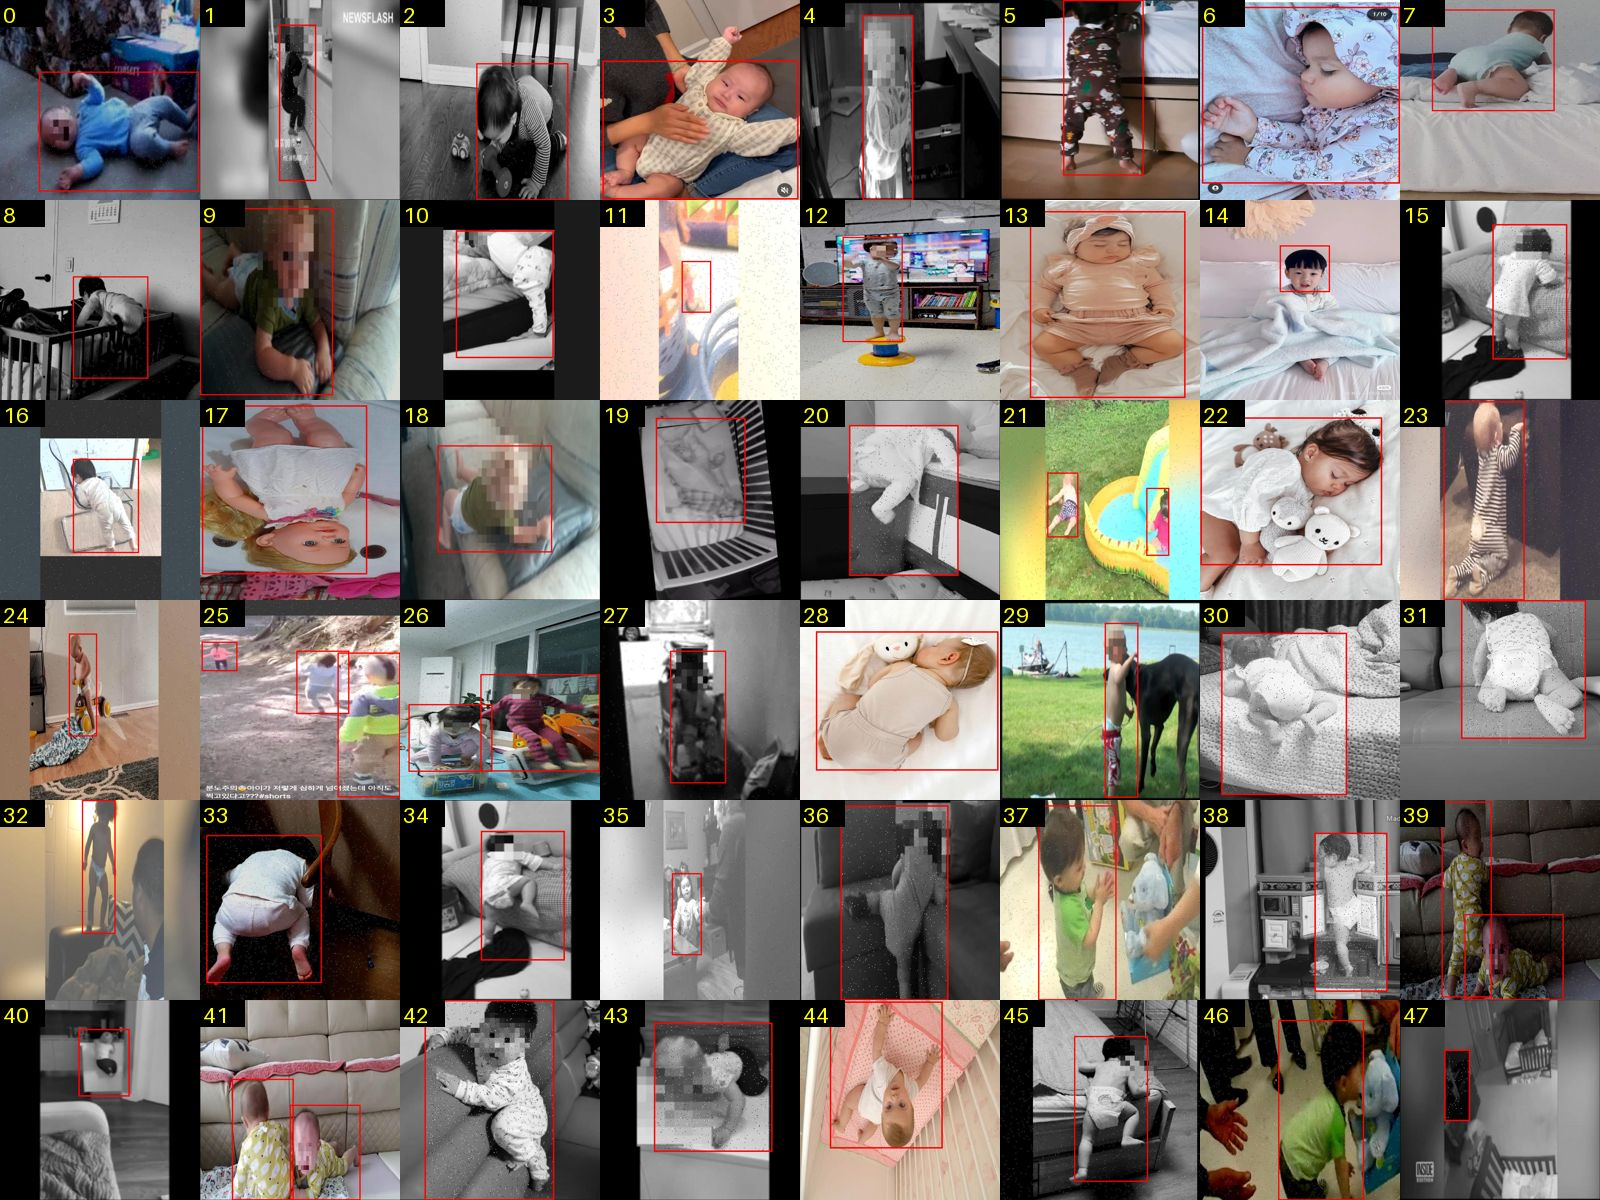

In [6]:
vtar = rf.workspace("vtar").project("baby-object-detection-final").version(1).download("yolov11")
!grep -E "nc:|names:" {vtar.location}/data.yaml

vt = sorted(glob.glob(f'{vtar.location}/*/images/*'))
videos = Counter(re.sub(r'-\d+$', '', base_id(f)) for f in vt)
print('images:', len(vt), '| videos:', len(videos))
for name, n in videos.most_common():
    print(n, name)

random.seed(0)
sheet(random.sample(vt, 48), '/content/vtar_sample.jpg')

## Find the test videos
I look at one frame from each large video to find the rooms that are in my test images.

0 2_mp4
1 babyfalling_mp4
2 baby_toyrefrigerator_climbing_mov
3 Wondershare_Filmora_2022-10-20_01-19-38_AdobeExpress_mp4
4 baby_sofa_climbing6_mov
5 Wondershare_Filmora_2022-10-20_00-39-12_AdobeExpress_mp4
6 Wondershare_Filmora_2022-10-20_02-19-39_AdobeExpress_mp4
7 Wondershare_Filmora_2022-10-20_02-07-57_AdobeExpress_mp4
8 baby_bed_climbing3_mov
9 baby_refrigerator_climbing_2_mp4
10 Wondershare_Filmora_2022-10-20_01-47-05_AdobeExpress_mp4
11 Wondershare_Filmora_2022-10-20_01-34-52_AdobeExpress_mp4
12 Wondershare_Filmora_2022-10-20_01-38-14_AdobeExpress_mp4
13 baby_bed_climbing_mov
14 baby_bed_climbing_9_mp4
15 baby_sofa_climbing4_mov
16 babyfallings2_mp4
17 Wondershare_Filmora_2022-10-20_01-03-27_AdobeExpress_mp4
18 baby_faint_video1_mp4
19 baby_chair_climbing6_mov
20 babyhitshishead_mp4
21 baby_sofa_climbing_2_mp4
22 baby_bed_climbing5_mov
23 baby_shelf_climbing2_mov
24 Wondershare_Filmora_2022-10-20_17-13-39_AdobeExpress_mp4
25 baby_faint_video2_mp4
26 0_mp4
27 baby_bed_climbing2_mo

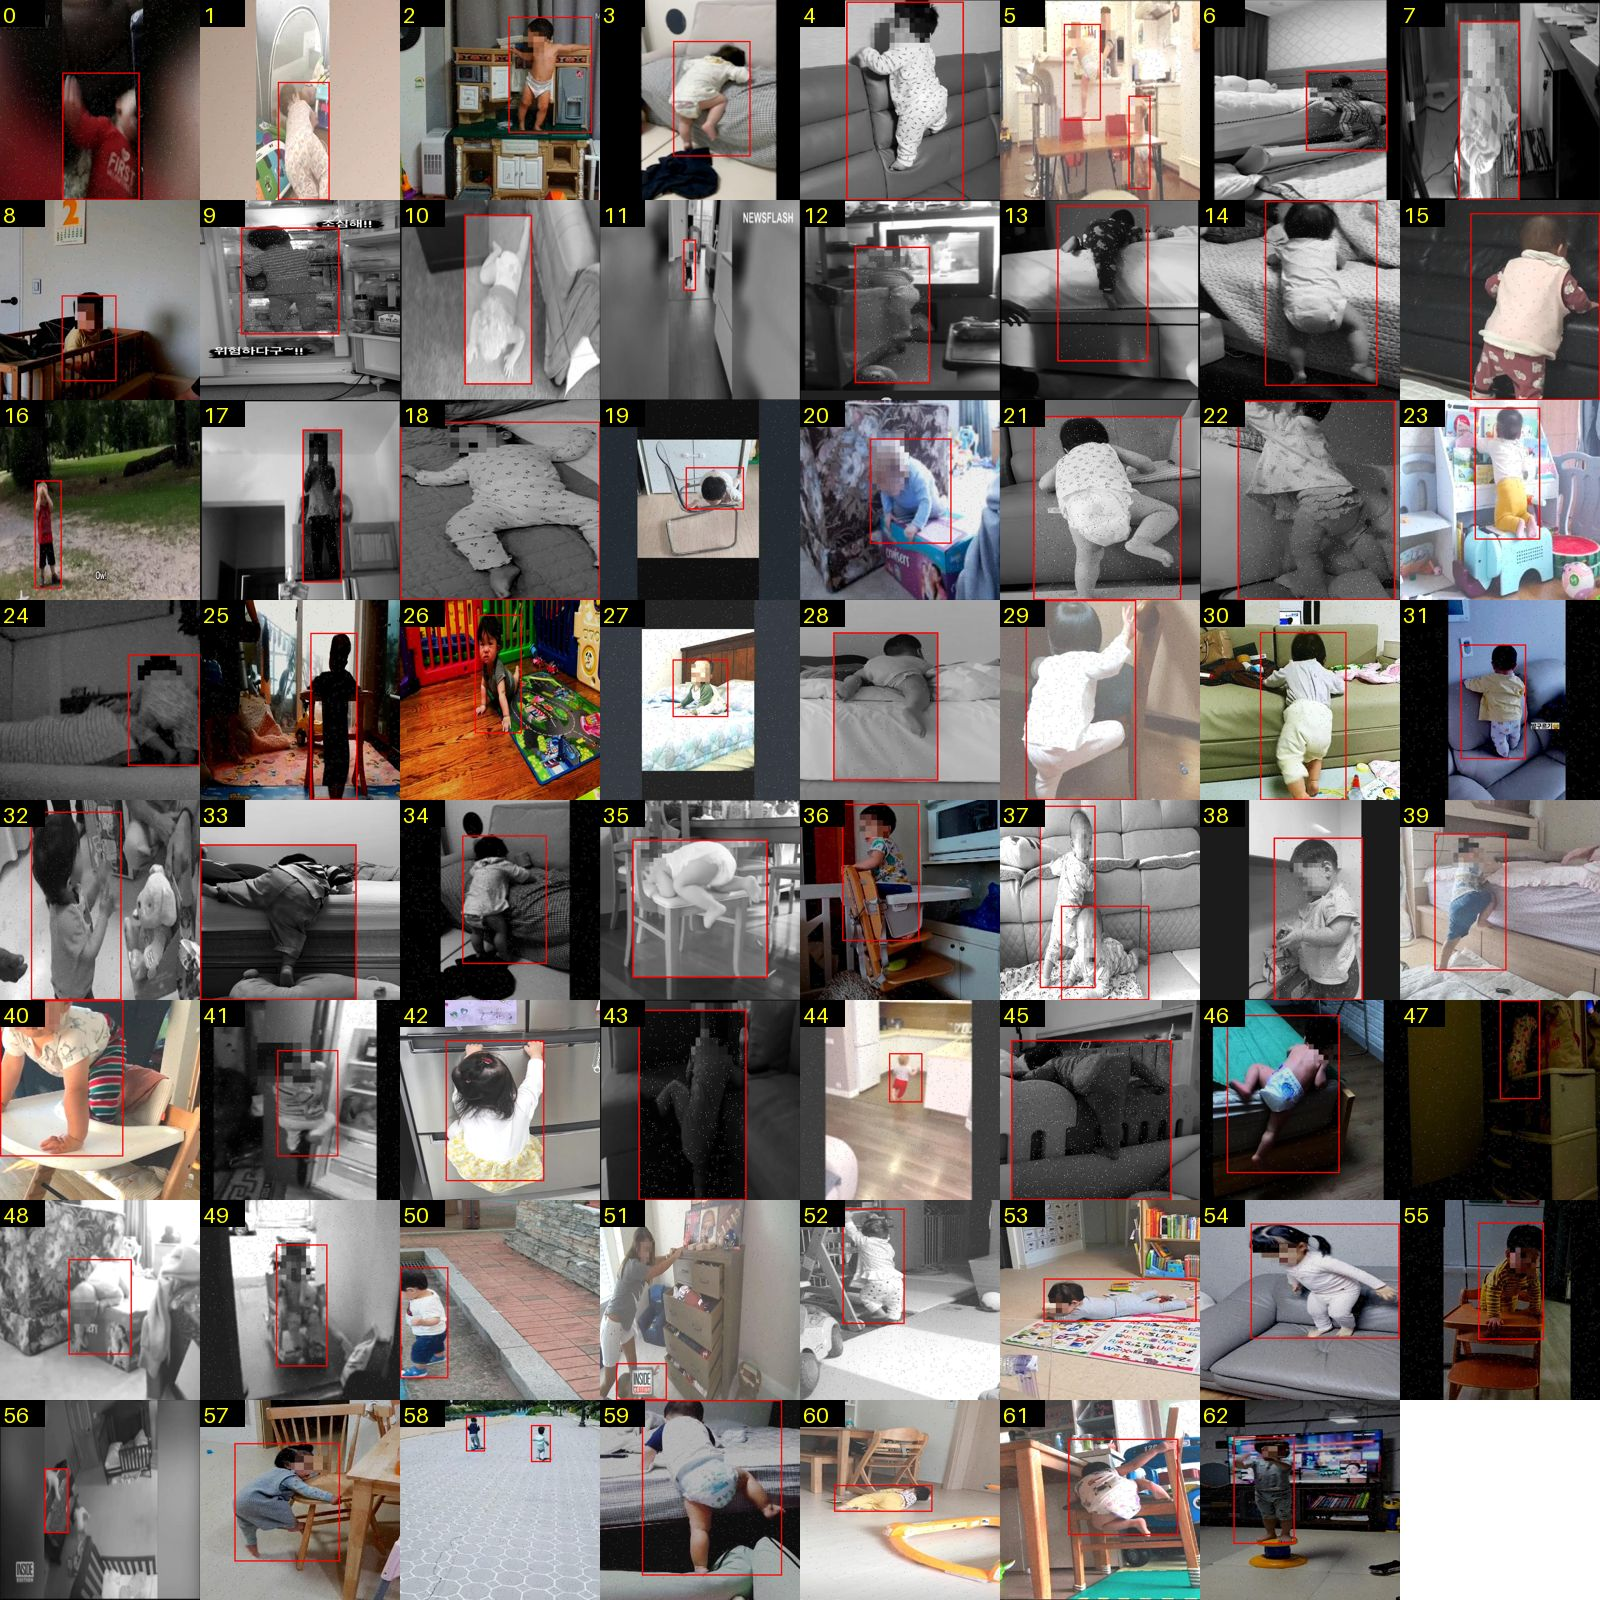

In [7]:
big = [name for name, n in videos.most_common() if n >= 20]
one = []
for name in big:
    frames = [f for f in vt if re.sub(r'-\d+$', '', base_id(f)) == name]
    one.append(frames[len(frames) // 2])

for i, name in enumerate(big):
    print(i, name)
sheet(one, '/content/vtar_videos.jpg')

## Build the folder again and train
I remove five videos that are, or can be, my test rooms. I use the same training settings as before.

In [8]:
shutil.rmtree(out)
for s in ['train', 'valid']:
    os.makedirs(f'{out}/{s}/images')
    os.makedirs(f'{out}/{s}/labels')

for s in ['train', 'valid']:
    for img in glob.glob(f'{bic.location}/{s}/images/*'):
        add(img, s, 'BC_', ['0'])

first = {}
for img in sorted(glob.glob('/content/BASE-crib-only-BABY-only-3/*/images/*')):
    first.setdefault(base_id(img), img)
for n, i in enumerate(sorted(first)):
    add(first[i], 'valid' if n % 10 == 0 else 'train', 'BA_', ['0'])
print('BASE original images:', len(first))

remove = ['baby_bed_climbing3_mov',
          'Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4',
          'babyfallings2_mp4', 'baby_news_mov', 'babyfalling_mp4']

def video(path):
    return re.sub(r'-\d+$', '', base_id(path))

first = {}
removed = 0
for img in vt:
    if video(img) in remove:
        removed += 1
        continue
    first.setdefault(base_id(img), img)
names = sorted(set(video(f) for f in first.values()))
valid_videos = set(names[::10])
for img in first.values():
    add(img, 'valid' if video(img) in valid_videos else 'train', 'VT_', ['0'])
print('VTAR files removed:', removed, '| original images kept:', len(first), '| videos:', len(names))

for s in ['train', 'valid']:
    a = len(glob.glob(f'{out}/{s}/images/*'))
    b = len(glob.glob(f'{out}/{s}/labels/*'))
    print(s, a, 'images', b, 'label files')
    assert a == b
assert not [f for f in glob.glob(f'{out}/*/images/VT_*') if any(r in f for r in remove)]

open(f'{out}/data.yaml', 'w').write(f"path: {out}\ntrain: train/images\nval: valid/images\nnc: 1\nnames: ['Child']\n")

import albumentations as A
from ultralytics import YOLO

model = YOLO('yolo11n.pt')
results = model.train(
    data=f'{out}/data.yaml',
    epochs=50, imgsz=640, batch=16,
    hsv_v=0.6, degrees=15,
    augmentations=[A.Blur(blur_limit=7, p=0.3)],
    project='/content/drive/MyDrive/crib_sentry_v2',
    name='child')

BASE original images: 309
VTAR files removed: 799 | original images kept: 3136 | videos: 918
train 3327 images 3327 label files
valid 336 images 336 label files
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=[{'__version__': '2.0.8', 'transform': {'__class_fullname__': 'Blur', 'p': 0.3, 'blur_limit': (3, 7)}}], auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ch

## Results
On 336 validation images: precision 0.948, recall 0.912, mAP50 0.976, mAP50-95 0.717.